In [1]:
import pandas as pd
import numpy as np


In [2]:
data = pd.read_csv('/content/drive/MyDrive/Resarch/Hepatitis C /HepatitisCdata.csv')
data.head()

,Unnamed: 0,Category,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
0,1,0=Blood Donor,32,m,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0
1,2,0=Blood Donor,32,m,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5
2,3,0=Blood Donor,32,m,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3
3,4,0=Blood Donor,32,m,43.2,52.0,30.6,22.6,18.9,7.33,4.74,80.0,33.8,75.7
4,5,0=Blood Donor,32,m,39.2,74.1,32.6,24.8,9.6,9.15,4.32,76.0,29.9,68.7


In [3]:
data.drop('Unnamed: 0', axis=1, inplace=True)

In [4]:
data.replace(to_replace=['0=Blood Donor', '0s=suspect Blood Donor',     '1=Hepatitis','2=Fibrosis', '3=Cirrhosis'],value=[0,1,2,3,4],inplace=True)

/tmp/ipython-input-4-3390712840.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.replace(to_replace=['0=Blood Donor', '0s=suspect Blood Donor',     '1=Hepatitis','2=Fibrosis', '3=Cirrhosis'],value=[0,1,2,3,4],inplace=True)


In [5]:
data['Category'].unique()

array([0, 1, 2, 3, 4])

In [6]:
data.head()

,Category,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
0,0,32,m,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0
1,0,32,m,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5
2,0,32,m,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3
3,0,32,m,43.2,52.0,30.6,22.6,18.9,7.33,4.74,80.0,33.8,75.7
4,0,32,m,39.2,74.1,32.6,24.8,9.6,9.15,4.32,76.0,29.9,68.7


In [7]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

print(data.isnull().sum())


for col in data.columns:
    if data[col].dtype == 'O':
        data[col].fillna(data[col].mode()[0], inplace=True)
    else:
        data[col].fillna(data[col].mean(), inplace=True)

# 3. Encode categorical variables
le = LabelEncoder()
data['Sex'] = le.fit_transform(data['Sex'])  # m=1, f=0

# 4. Separate features and target
X = data.drop('Category', axis=1)
y = data['Category']

# 5. Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 6. Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)


Category     0
Age          0
Sex          0
ALB          1
ALP         18
ALT          1
AST          0
BIL          0
CHE          0
CHOL        10
CREA         0
GGT          0
PROT         1
dtype: int64
(492, 12) (123, 12) (492,) (123,)


/tmp/ipython-input-7-1492337618.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].mean(), inplace=True)
/tmp/ipython-input-7-1492337618.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', t

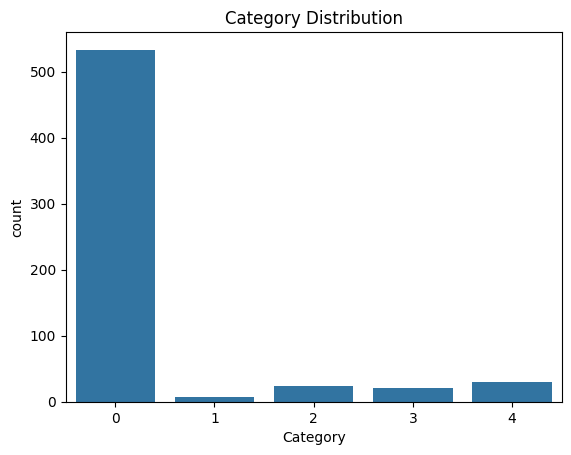

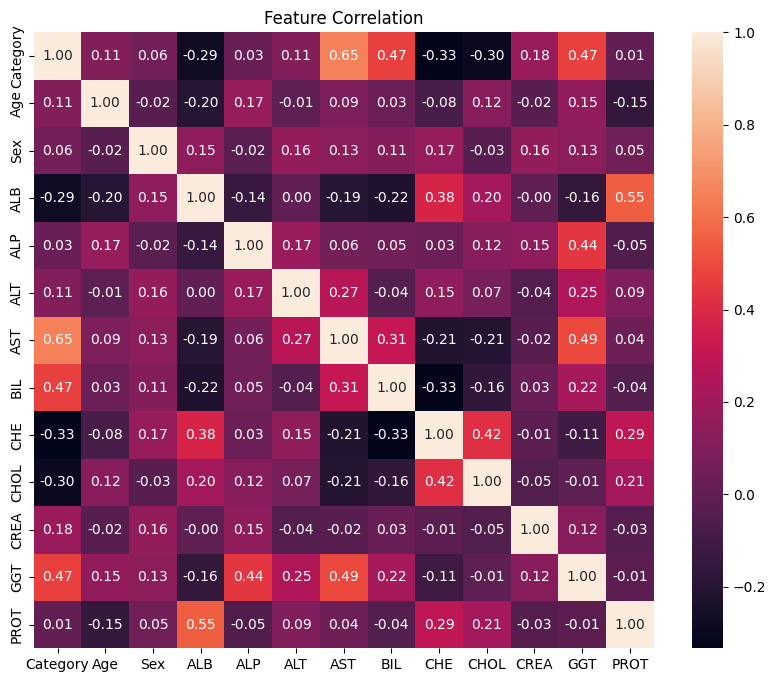

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Class distribution
sns.countplot(x='Category', data=data)
plt.title('Category Distribution')
plt.show()

# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), annot=True, fmt='.2f')
plt.title('Feature Correlation')
plt.show()


In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Train model
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Predict
y_pred = clf.predict(X_test)

# Evaluate
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.96      1.00      0.98       107
           1       0.00      0.00      0.00         1
           2       0.33      0.20      0.25         5
           3       0.67      0.50      0.57         4
           4       1.00      0.83      0.91         6

    accuracy                           0.93       123
   macro avg       0.59      0.51      0.54       123
weighted avg       0.92      0.93      0.92       123

[[107   0   0   0   0]
 [  1   0   0   0   0]
 [  3   0   1   1   0]
 [  0   0   2   2   0]
 [  1   0   0   0   5]]


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [10]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical


In [11]:
def print_metrics(y_true, y_pred, labels=None):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average=None, labels=labels)
    prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
    print(f"Accuracy: {acc:.4f}")
    print("\nPrecision (per class):", prec)
    print("Recall (per class):", rec)
    print("F1-score (per class):", f1)
    print(f"\nMacro Precision: {prec_macro:.4f}, Macro Recall: {rec_macro:.4f}, Macro F1: {f1_macro:.4f}")
    print("\nClassification Report:\n", classification_report(y_true, y_pred))
    print("\nConfusion Matrix:\n", confusion_matrix(y_true, y_pred))


In [12]:
def evaluate_model(model, X, y, name="Model"):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    y_pred = cross_val_predict(model, X, y, cv=skf)
    print(f"\n{'='*20}\n{name} Results\n{'='*20}")
    print_metrics(y, y_pred, labels=np.unique(y))


In [14]:
# One-hot encode labels for Keras
num_classes = len(np.unique(y))
y_cat = to_categorical(y, num_classes=num_classes)

# Function to create MLP
def create_mlp(input_dim, num_classes):
    model = Sequential([
        Dense(128, activation='relu', input_dim=input_dim),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# 5-fold CV for Keras MLP
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
mlp_preds = np.zeros(y.shape, dtype=int)

for i, (train_idx, test_idx) in enumerate(skf.split(X_scaled, y)):
    print(f"\n--- MLP Fold {i+1} ---")
    X_tr, X_te = X_scaled[train_idx], X_scaled[test_idx]
    y_tr, y_te = y_cat[train_idx], y[test_idx]
    model = create_mlp(X_tr.shape[1], num_classes)
    model.fit(X_tr, y_tr, epochs=40, batch_size=32, verbose=0)
    pred = np.argmax(model.predict(X_te), axis=1)
    mlp_preds[test_idx] = pred

print(f"\n{'='*20}\nDeep Learning MLP Results\n{'='*20}")
print_metrics(y, mlp_preds, labels=np.unique(y))



--- MLP Fold 1 ---


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

--- MLP Fold 2 ---


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

--- MLP Fold 3 ---


...

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- MLP Fold 4 ---
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

--- MLP Fold 5 ---


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

Deep Learning MLP Results
Accuracy: 0.9317

Precision (per class): [0.96363636 0.66666667 0.52380952 0.53333333 0.84615385]
Recall (per class): [0.99437148 0.28571429 0.45833333 0.38095238 0.73333333]
F1-score (per class): [0.9787627  0.4        0.48888889 0.44444444 0.78571429]

Macro Precision: 0.7067, Macro Recall: 0.5705, Macro F1: 0.6196

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.99      0.98       533
           1       0.67      0.29      0.40         7
           2       0.52      0.46      0.49        24
           3       0.53      0.38      0.44        21
           4       0.85      0.73      0.79        30

    accuracy                           0.93       615
   macro avg       0.71      0.57      0.62       615
weighted avg       0.92      0.93      0.93       615


Confusion Matrix:
 [[530   1   1   1   0]
 [  4   2   0   0   1]
 [  9   0  11   2   2]
 [  6   0   6

In [15]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             classification_report)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier

In [16]:
models = {
    'SVM': SVC(probability=True, random_state=42),
    'KNN': KNeighborsClassifier(),
    'RandomForest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
    'GradBoost': GradientBoostingClassifier(random_state=42),
    'ExtraTrees': ExtraTreesClassifier(random_state=42)
}

param_grids = {
    'SVM': {'C': [0.1, 1, 10], 'kernel': ['rbf', 'linear']},
    'KNN': {'n_neighbors': [3, 5, 7]},
    'RandomForest': {'n_estimators': [100, 200], 'max_depth': [None, 10, 20]},
    'XGBoost': {'n_estimators': [100, 200], 'max_depth': [3, 6]},
    'GradBoost': {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1]},
    'ExtraTrees': {'n_estimators': [100, 200], 'max_depth': [None, 10, 20]}
}


In [17]:
scoring_metrics = {
    'accuracy': 'accuracy',
    'precision_macro': 'precision_macro',
    'recall_macro': 'recall_macro',
    'f1_macro': 'f1_macro',
    'roc_auc_ovr': 'roc_auc_ovr'
}

results = []

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    print(f"\nTraining and tuning: {name}")
    grid = GridSearchCV(model, param_grids[name], cv=cv, n_jobs=-1, scoring='accuracy')
    grid.fit(X_scaled, y)
    best_model = grid.best_estimator_
    y_pred = cross_val_predict(best_model, X_scaled, y, cv=cv, method='predict')
    y_prob = cross_val_predict(best_model, X_scaled, y, cv=cv, method='predict_proba')

    # ROC AUC for multiclass
    try:
        roc_auc = roc_auc_score(pd.get_dummies(y), y_prob, average='macro', multi_class='ovr')
    except:
        roc_auc = np.nan

    acc = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred, average='macro', zero_division=0)
    rec = recall_score(y, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y, y_pred, average='macro', zero_division=0)

    cv_scores = cross_val_predict(best_model, X_scaled, y, cv=cv, method='predict')
    cv_acc = np.mean(cv_scores == y)

    results.append({
        'Model': name,
        'Best Params': grid.best_params_,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-score': f1,
        'ROC AUC': roc_auc,
        'CV Accuracy': cv_acc
    })



Training and tuning: SVM

Training and tuning: KNN

Training and tuning: RandomForest

Training and tuning: XGBoost


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:05:42] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:05:43] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:05:43] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:05:44] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:05:44] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e


Training and tuning: GradBoost

Training and tuning: ExtraTrees


In [18]:
results_df = pd.DataFrame(results)
results_df = results_df[['Model', 'Best Params', 'Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC AUC', 'CV Accuracy']]
display(results_df)


,Model,Best Params,Accuracy,Precision,Recall,F1-score,ROC AUC,CV Accuracy
0,SVM,"{'C': 10, 'kernel': 'linear'}",0.923577,0.678885,0.611284,0.640600,0.966196,0.923577
1,KNN,{'n_neighbors': 5},0.899187,0.633765,0.375815,0.426973,0.839766,0.899187
2,RandomForest,"{'max_depth': 10, 'n_estimators': 100}",0.926829,0.545975,0.490916,0.510617,0.970048,0.926829
3,XGBoost,"{'max_depth': 3, 'n_estimators': 200}",0.923577,0.699695,0.529350,0.573052,0.963230,0.923577
4,GradBoost,"{'learning_rate': 0.1, 'n_estimators': 200}",0.930081,0.715078,0.607684,0.653935,0.945878,0.930081
5,ExtraTrees,"{'max_depth': 20, 'n_estimators': 200}",0.921951,0.745561,0.508535,0.570894,0.976055,0.921951


In [19]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

models = {
    'SVM': SVC(C=1, kernel='rbf', probability=True, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', n_estimators=100, random_state=42),
    'GradBoost': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'ExtraTrees': ExtraTreesClassifier(n_estimators=100, random_state=42)
}

cv_scores = {}

for name, model in models.items():
    scores = cross_val_score(model, X_scaled, y, cv=5, scoring='accuracy')
    cv_scores[name] = scores
    print(f"{name} CV Accuracies: {scores}")


SVM CV Accuracies: [0.91869919 0.92682927 0.92682927 0.88617886 0.89430894]
KNN CV Accuracies: [0.91056911 0.90243902 0.91869919 0.87804878 0.90243902]
RandomForest CV Accuracies: [0.94308943 0.94308943 0.93495935 0.90243902 0.88617886]


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:08:38] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:08:40] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:08:40] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:08:40] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:08:40] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

XGBoost CV Accuracies: [0.94308943 0.93495935 0.96747967 0.91056911 0.90243902]
GradBoost CV Accuracies: [0.93495935 0.92682927 0.92682927 0.91869919 0.91056911]
ExtraTrees CV Accuracies: [0.92682927 0.93495935 0.93495935 0.89430894 0.90243902]


In [20]:
from scipy.stats import ttest_rel
import pandas as pd

model_names = list(models.keys())
pval_matrix = pd.DataFrame(np.ones((len(models), len(models))), columns=model_names, index=model_names)

for i, name1 in enumerate(model_names):
    for j, name2 in enumerate(model_names):
        if i < j:  # Only upper triangle
            t_stat, p_val = ttest_rel(cv_scores[name1], cv_scores[name2])
            pval_matrix.loc[name1, name2] = p_val
            pval_matrix.loc[name2, name1] = p_val  # Symmetric

print("\nPaired t-test p-value matrix (accuracy, 5-fold CV):")
print(pval_matrix)



Paired t-test p-value matrix (accuracy, 5-fold CV):
                       SVM       KNN  RandomForest   XGBoost  GradBoost  \
SVM           1.000000e+00  0.189004      0.107939  0.025481   0.099301   
KNN           1.890037e-01  1.000000      0.117955  0.021312   0.025481   
RandomForest  1.079388e-01  0.117955      1.000000  0.235496   0.846643   
XGBoost       2.548148e-02  0.021312      0.235496  1.000000   0.412954   
GradBoost     9.930068e-02  0.025481      0.846643  0.412954   1.000000   
ExtraTrees    7.513745e-58  0.034109      0.587050  0.099301   0.467605   

                ExtraTrees  
SVM           7.513745e-58  
KNN           3.410942e-02  
RandomForest  5.870496e-01  
XGBoost       9.930068e-02  
GradBoost     4.676048e-01  
ExtraTrees    1.000000e+00  


# after smote

In [21]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE to training data
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_scaled, y)

# Print new class distribution
from collections import Counter
print("Class distribution after SMOTE:", Counter(y_smote))


Class distribution after SMOTE: Counter({0: 533, 1: 533, 2: 533, 3: 533, 4: 533})


In [22]:
cv_scores_smote = {}

for name, model in models.items():
    scores = cross_val_score(model, X_smote, y_smote, cv=5, scoring='accuracy')
    cv_scores_smote[name] = scores
    print(f"{name} (SMOTE) CV Accuracies: {scores}")


SVM (SMOTE) CV Accuracies: [0.91369606 0.96998124 0.94934334 0.96998124 0.96810507]
KNN (SMOTE) CV Accuracies: [0.93058161 0.98686679 0.96435272 0.97373358 0.97185741]
RandomForest (SMOTE) CV Accuracies: [0.97373358 0.99624765 0.98499062 1.         0.99249531]


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:10:24] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:10:24] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:10:24] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:10:25] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:10:25] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

XGBoost (SMOTE) CV Accuracies: [0.94371482 0.99061914 0.98499062 1.         0.98874296]
GradBoost (SMOTE) CV Accuracies: [0.96247655 0.99061914 0.98686679 0.99437148 0.98311445]
ExtraTrees (SMOTE) CV Accuracies: [0.96998124 0.99437148 0.99249531 1.         0.99249531]


In [23]:
results_smote = []

for name, model in models.items():
    y_pred = cross_val_predict(model, X_smote, y_smote, cv=5, method='predict')
    y_prob = cross_val_predict(model, X_smote, y_smote, cv=5, method='predict_proba')
    try:
        roc_auc = roc_auc_score(pd.get_dummies(y_smote), y_prob, average='macro', multi_class='ovr')
    except:
        roc_auc = np.nan

    acc = accuracy_score(y_smote, y_pred)
    prec = precision_score(y_smote, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_smote, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_smote, y_pred, average='macro', zero_division=0)
    cv_acc = np.mean(y_smote == y_pred)
    results_smote.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-score': f1,
        'ROC AUC': roc_auc,
        'CV Accuracy': cv_acc
    })

results_df_smote = pd.DataFrame(results_smote)
display(results_df_smote)


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:11:29] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:11:30] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:11:30] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:11:31] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:11:32] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

,Model,Accuracy,Precision,Recall,F1-score,ROC AUC,CV Accuracy
0,SVM,0.954221,0.957317,0.954221,0.954529,0.997953,0.954221
1,KNN,0.965478,0.967631,0.965478,0.964577,0.992246,0.965478
2,RandomForest,0.989493,0.989621,0.989493,0.989477,0.999858,0.989493
3,XGBoost,0.981614,0.982177,0.981614,0.981523,0.999436,0.981614
4,GradBoost,0.983490,0.983814,0.983490,0.983473,0.999279,0.983490
5,ExtraTrees,0.989869,0.990086,0.989869,0.989839,0.999931,0.989869


In [24]:
pval_matrix_smote = pd.DataFrame(np.ones((len(models), len(models))), columns=model_names, index=model_names)

for i, name1 in enumerate(model_names):
    for j, name2 in enumerate(model_names):
        if i < j:
            t_stat, p_val = ttest_rel(cv_scores_smote[name1], cv_scores_smote[name2])
            pval_matrix_smote.loc[name1, name2] = p_val
            pval_matrix_smote.loc[name2, name1] = p_val

print("\nPaired t-test p-value matrix (accuracy, 5-fold CV, SMOTE data):")
print(pval_matrix_smote)



Paired t-test p-value matrix (accuracy, 5-fold CV, SMOTE data):
                   SVM       KNN  RandomForest   XGBoost  GradBoost  \
SVM           1.000000  0.021743      0.005540  0.000741   0.008788   
KNN           0.021743  1.000000      0.012113  0.012970   0.020476   
RandomForest  0.005540  0.012113      1.000000  0.234960   0.056000   
XGBoost       0.000741  0.012970      0.234960  1.000000   0.696836   
GradBoost     0.008788  0.020476      0.056000  0.696836   1.000000   
ExtraTrees    0.004521  0.009414      0.854080  0.150944   0.002629   

              ExtraTrees  
SVM             0.004521  
KNN             0.009414  
RandomForest    0.854080  
XGBoost         0.150944  
GradBoost       0.002629  
ExtraTrees      1.000000  


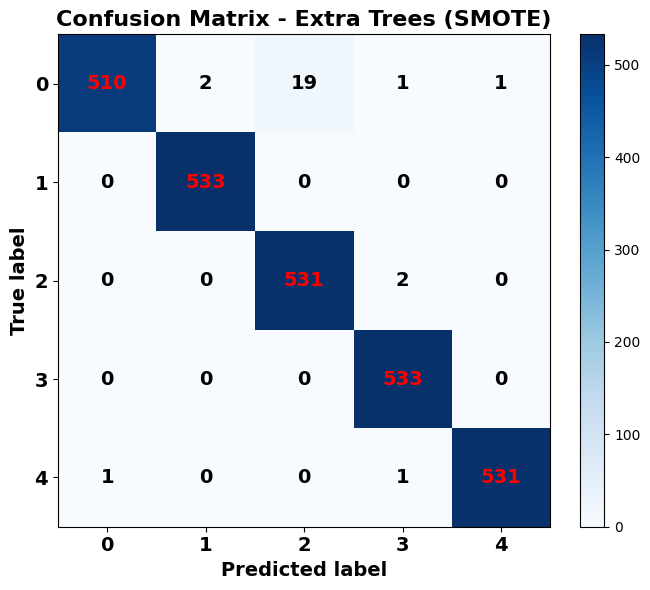

In [33]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_smote, y_pred_et)
labels = np.unique(y_smote)

fig, ax = plt.subplots(figsize=(8, 6))

# Show the confusion matrix as an image
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title('Confusion Matrix - Extra Trees (SMOTE)', fontsize=16, fontweight='bold')
plt.colorbar(im, fraction=0.046, pad=0.04)

# Axis labels and ticks
ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels, fontsize=14, fontweight='bold')
ax.set_yticklabels(labels, fontsize=14, fontweight='bold')
plt.xlabel('Predicted label', fontsize=14, fontweight='bold')
plt.ylabel('True label', fontsize=14, fontweight='bold')

# Annotate each cell with the numeric value (big, bold)
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                fontsize=14, fontweight='bold',
                color="red" if cm[i, j] > thresh else "black")

plt.tight_layout()
plt.savefig('confusion_matrix_et_smote.png')
plt.show()


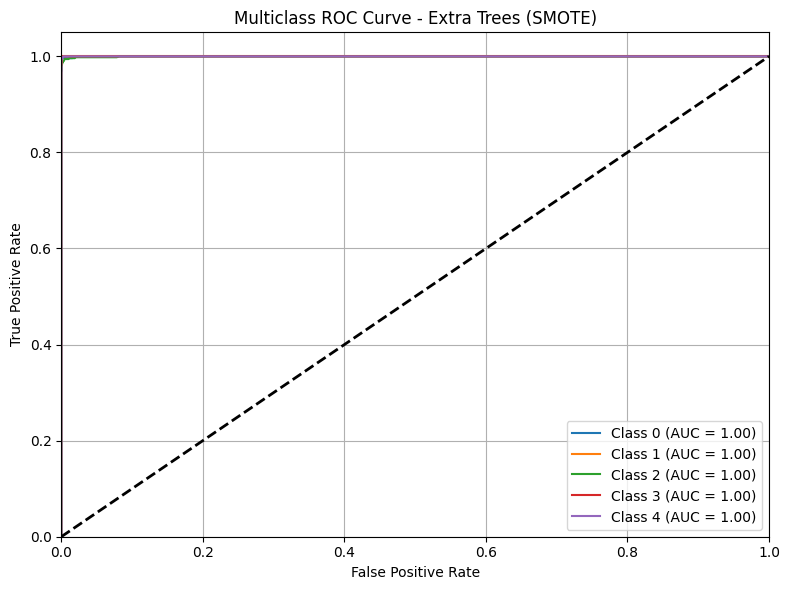

In [34]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Binarize labels for multiclass ROC
n_classes = len(np.unique(y_smote))
y_bin = label_binarize(y_smote, classes=np.unique(y_smote))

# Cross-validated probability predictions
y_score = cross_val_predict(best_et, X_smote, y_smote, cv=5, method='predict_proba')

# Plot ROC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

plt.figure(figsize=(8,6))
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve - Extra Trees (SMOTE)')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.savefig('roc_curve_et_smote.png')
plt.show()


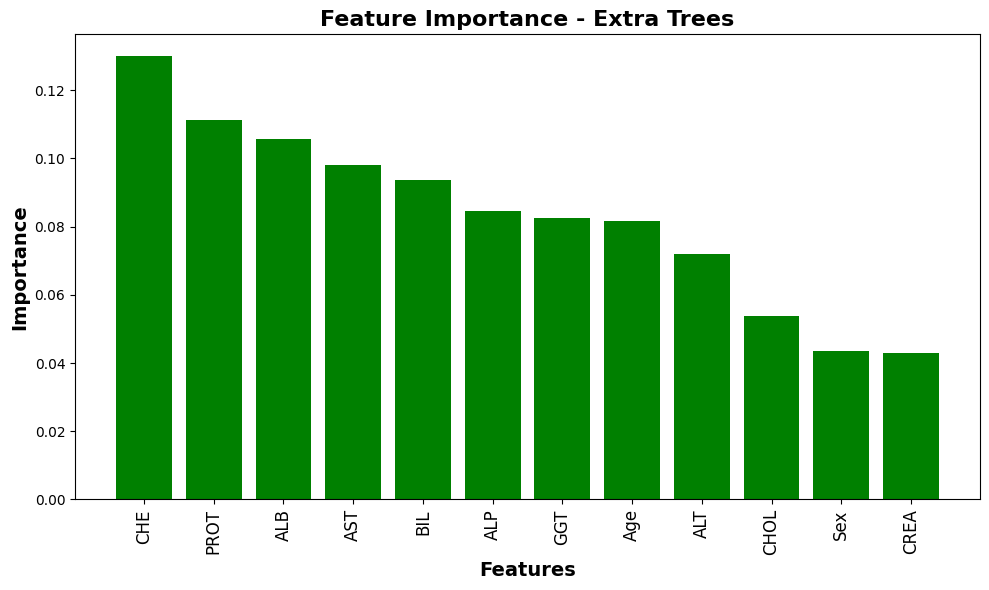

In [35]:
import matplotlib.pyplot as plt
import pandas as pd

# Fit Extra Trees on SMOTE data
best_et.fit(X_smote, y_smote)
importances = best_et.feature_importances_
feature_names = X.columns  # Change if your feature variable names are different

# Sort importances
indices = np.argsort(importances)[::-1]
sorted_features = [feature_names[i] for i in indices]
sorted_importances = importances[indices]

plt.figure(figsize=(10, 6))
plt.bar(range(len(importances)), sorted_importances, color='g', align='center')
plt.xticks(range(len(importances)), sorted_features, rotation=90, fontsize=12)
plt.xlabel('Features', fontsize=14, fontweight='bold')
plt.ylabel('Importance', fontsize=14, fontweight='bold')
plt.title('Feature Importance - Extra Trees', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance_et_smote.png')
plt.show()


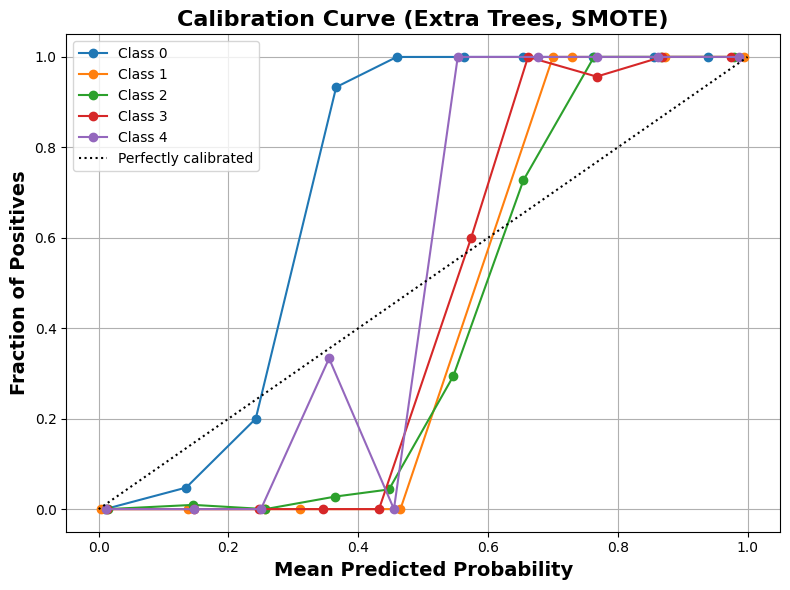

In [36]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

# Get probability predictions
y_proba_et = cross_val_predict(best_et, X_smote, y_smote, cv=5, method='predict_proba')

# For multiclass: plot calibration for each class
plt.figure(figsize=(8,6))
for i, label in enumerate(np.unique(y_smote)):
    prob_true, prob_pred = calibration_curve((y_smote == label).astype(int), y_proba_et[:, i], n_bins=10)
    plt.plot(prob_pred, prob_true, marker='o', label=f'Class {label}')

plt.plot([0, 1], [0, 1], "k:", label="Perfectly calibrated")
plt.xlabel("Mean Predicted Probability", fontsize=14, fontweight='bold')
plt.ylabel("Fraction of Positives", fontsize=14, fontweight='bold')
plt.title("Calibration Curve (Extra Trees, SMOTE)", fontsize=16, fontweight='bold')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('calibration_curve_et_smote.png')
plt.show()


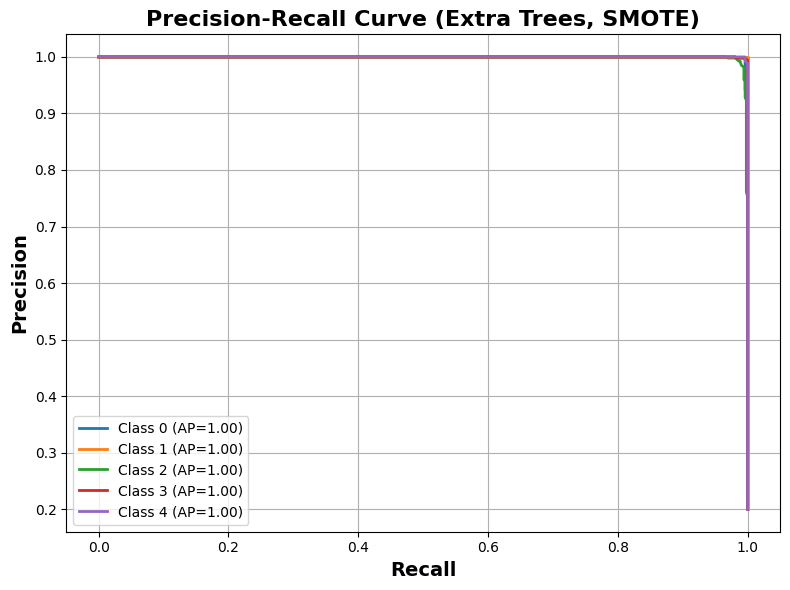

In [37]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(8,6))
for i, label in enumerate(np.unique(y_smote)):
    # Binarize labels for "one vs rest"
    y_true_bin = (y_smote == label).astype(int)
    precision, recall, _ = precision_recall_curve(y_true_bin, y_proba_et[:, i])
    avg_prec = average_precision_score(y_true_bin, y_proba_et[:, i])
    plt.plot(recall, precision, lw=2, label=f'Class {label} (AP={avg_prec:.2f})')

plt.xlabel("Recall", fontsize=14, fontweight='bold')
plt.ylabel("Precision", fontsize=14, fontweight='bold')
plt.title("Precision-Recall Curve (Extra Trees, SMOTE)", fontsize=16, fontweight='bold')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('pr_curve_et_smote.png')
plt.show()
